In [1]:
%run start
%load_ext autoreload
%autoreload 2

Root set to: /home/bdudas/obesity_challange


In [2]:
from src.data.perturbation_data import get_loaders
import pytorch_lightning as pl
from lightning.pytorch.loggers import MLFlowLogger
from omegaconf import OmegaConf
from pytorch_lightning.callbacks import ModelCheckpoint


/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg = OmegaConf.load("configs/cycle_transformer.yaml")

In [5]:
trainloader, valloader, gene_to_index, index_to_gene = get_loaders("",batch_size=cfg.batch_size,num_workers=cfg.num_workers)  

In [6]:
from src.models.CycleTransformer import CycleTransformer


In [7]:
cpkt_name ="latent_reg"
pretrained_path = f"misc/best_runs/{cpkt_name}/checkpoints/best-checkpoint.ckpt"
model = CycleTransformer.load_from_checkpoint(checkpoint_path = pretrained_path)#(**modelKwargs)
model.configure_cycle()

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [ ]:
cpkt_callback = ModelCheckpoint(monitor="val/g_total_loss",mode="min",save_top_k=1,filename="best-checkpoint")
mlflow_logger = MLFlowLogger(experiment_name=cfg.experiment_name,run_name=cfg.run_name)
trainer = pl.Trainer(max_epochs=cfg.max_epochs,logger=mlflow_logger,accelerator="auto",devices="auto" ,callbacks=[cpkt_callback])


/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

   | Name             | Type                      | Params | Mode  | FLOPs
--------------------------------------------------------------------------------
0  | encoder          | TransformerCycleEncoder   | 5.4 M  | eval  | 0    
1  | decoder          | TransformerCycleDecoder   | 5.4 M  | eval  | 0    
2  | transition       | LatentTransition2         | 7.9 M  | eval  | 0    
3  | latentClassifier | LatentClassifier          | 33.7 K | eval  | 0    
4  | criterion        | MSELoss                   | 0      | train | 0    
5  | latent_criterion | CrossEntropyLoss          | 0      | train | 0    
6  | center_loss      | CenterLoss                | 1.0 K  | train | 0    
7  | aucMetric        | MulticlassAUROC           | 0      | train | 0    
8  | confmat          | MulticlassConfusionMatrix | 0      | train | 0    
9  | confmat2         | MulticlassConfusionMatrix | 0      | train | 0    
10 | classwise_auc    | ClasswiseWrap

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 128 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 0: 100%|██████████| 493/493 [00:48<00:00, 10.11it/s, v_num=0b0b, Train/loss_cycle_ctrl=0.016, Train/loss_cycle_pert=0.00778, Train/loss_adv_g=0.596, Train/loss_sem_ctrl=0.0572, Train/loss_sem_pert=0.0257, Train/loss_mmd=0.0015, Train/d_loss=0.306, Train/d_real=0.167, Train/d_fake=0.267]      

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


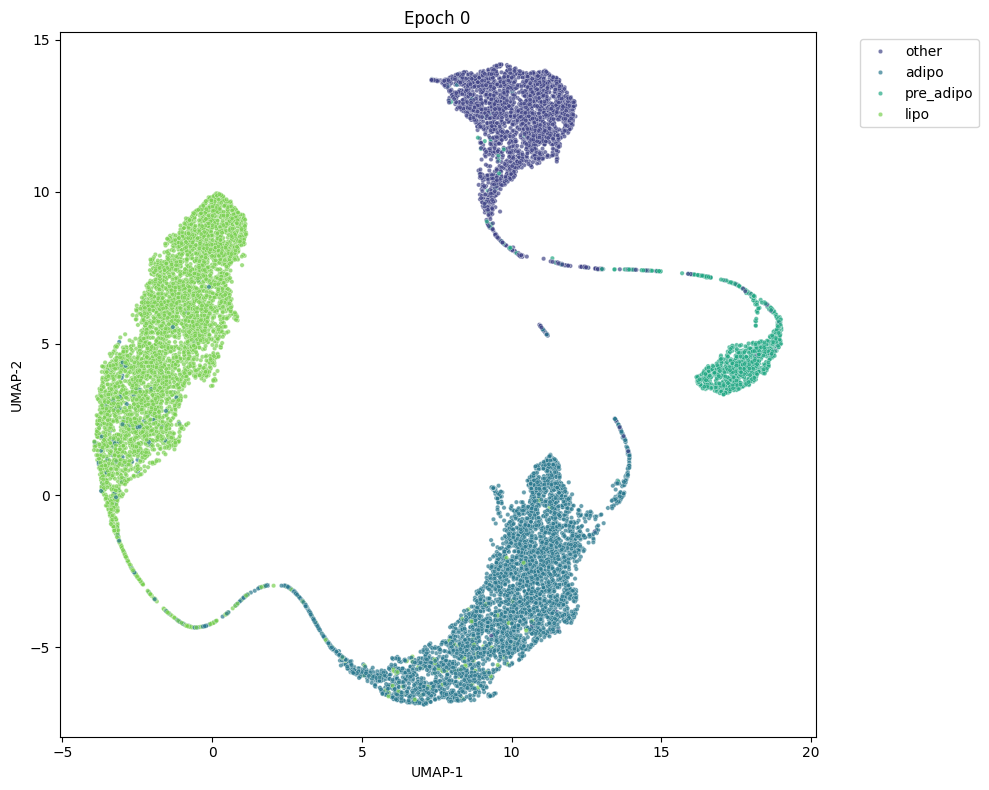

Epoch 0: 100%|██████████| 493/493 [01:34<00:00,  5.24it/s, v_num=0b0b, Train/loss_cycle_ctrl=0.016, Train/loss_cycle_pert=0.00778, Train/loss_adv_g=0.596, Train/loss_sem_ctrl=0.0572, Train/loss_sem_pert=0.0257, Train/loss_mmd=0.0015, Train/d_loss=0.306, Train/d_real=0.167, Train/d_fake=0.267, val/loss_cycle_ctrl=0.0337, val/loss_cycle_pert=0.0931, val/loss_adv_g=0.616, val/loss_sem_ctrl=0.0662, val/loss_sem_pert=0.074, val/loss_mmd=0.00159]

MisconfigurationException: `ModelCheckpoint(monitor='val/total_loss')` could not find the monitored key in the returned metrics: ['Train/loss_cycle_ctrl', 'Train/loss_cycle_pert', 'Train/loss_adv_g', 'Train/loss_sem_ctrl', 'Train/loss_sem_pert', 'Train/loss_mmd', 'Classification/Train/AUROC_Real_pre_adipo', 'Classification/Train/AUROC_Real_adipo', 'Classification/Train/AUROC_Real_lipo', 'Classification/Train/AUROC_Real_other', 'Classification/Train/AUROC_pre_adipo', 'Classification/Train/AUROC_adipo', 'Classification/Train/AUROC_lipo', 'Classification/Train/AUROC_other', 'Train/Health_Delta_Mag', 'Train/Health_Movement_Ratio', 'Train/Health_Diversity_Real', 'Train/Health_Diversity_Fake', 'Train/Health_Diversity_Ratio', 'Train/Health_Delta_Diversity', 'Train/d_loss', 'Train/d_real', 'Train/d_fake', 'val/loss_cycle_ctrl', 'val/loss_cycle_pert', 'val/loss_adv_g', 'val/loss_sem_ctrl', 'val/loss_sem_pert', 'val/loss_mmd', 'Classification/val/AUROC_Real_pre_adipo', 'Classification/val/AUROC_

In [9]:
trainer.fit(model,train_dataloaders=trainloader, val_dataloaders=valloader)